# 📡 No-Churn Telecom — Customer Churn Prediction
**Project Ref:** PM-PR-0017  
**Client:** No-Churn Telecom  
**Category:** Telecom – Churn Rate Machine Learning  

---

## Project Goals
1. Identify the key variables influencing customer churn  
2. Predict customers likely to churn  
3. Generate a new variable `CHURN_FLAG` (YES=1 / NO=0)  
4. Enable marketing & support teams to target high-risk customers  

---
### Notebook Structure
| # | Section |
|---|---|
| 1 | Imports & Setup |
| 2 | Data Loading (CSV + SQL simulation) |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Pre-processing & Pipeline |
| 6 | Model Building & Evaluation |
| 7 | Best Model Selection |
| 8 | CHURN_FLAG Generation |
| 9 | Business Insights & Recommendations |

## 1. Imports & Setup

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

from scipy import stats

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 2. Data Loading

### 2a. SQL Query Simulation
The project spec references a live MySQL database. Below is the SQL query that would be used in production to pull the data. We then load it from the provided CSV for this notebook.

In [2]:
# ── SQL Connection Details (Production) ───────────────────────────────────────
# Host     : 18.136.157.135
# Schema   : project_telecom
# Table    : telecom_churn_data
# Username : dm_team3

SQL_QUERY = """
-- ============================================================
--  No-Churn Telecom  |  Churn Data Extraction
--  Schema  : project_telecom
--  Table   : telecom_churn_data
-- ============================================================

SELECT
    customer_id,
    telecom_partner,
    gender,
    age,
    state,
    city,
    pincode,
    date_of_registration,
    num_dependents,
    estimated_salary,
    calls_made,
    sms_sent,
    data_used,
    churn
FROM
    project_telecom.telecom_churn_data
WHERE
    date_of_registration IS NOT NULL
    AND customer_id IS NOT NULL
ORDER BY
    customer_id;
"""

print('📋 SQL Query ready.')
print(SQL_QUERY)

# ── Production connection code (commented out — requires MySQL driver) ─────────
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host='18.136.157.135',
    database='project_telecom',
    user='dm_team3',
    password='DM!$!Team!27@9!20&'
)

query = """
SELECT *
FROM project_telecom.telecom_churn_data
WHERE customer_id BETWEEN 1 AND 1000
ORDER BY customer_id
"""

df = pd.read_sql(query, conn)
conn.close()

print(df.shape)
df

📋 SQL Query ready.

-- ============================================================
--  No-Churn Telecom  |  Churn Data Extraction
--  Schema  : project_telecom
--  Table   : telecom_churn_data
-- ============================================================

SELECT
    customer_id,
    telecom_partner,
    gender,
    age,
    state,
    city,
    pincode,
    date_of_registration,
    num_dependents,
    estimated_salary,
    calls_made,
    sms_sent,
    data_used,
    churn
FROM
    project_telecom.telecom_churn_data
WHERE
    date_of_registration IS NOT NULL
    AND customer_id IS NOT NULL
ORDER BY
    customer_id;

(1000, 14)


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,BSNL,F,19,Tamil Nadu,Delhi,326273,2020-01-05,0,81532,29,36,3952,0
996,997,Airtel,M,38,Nagaland,Kolkata,126707,2020-01-05,4,127367,39,19,5328,0
997,998,Vodafone,M,18,Odisha,Chennai,742600,2020-01-05,1,120764,49,42,6260,1
998,999,Vodafone,M,64,Tripura,Delhi,186458,2020-01-05,1,95036,96,12,2262,0


In [3]:
# Check for duplicates in the SQL data
print("Total rows:", len(df))
print("Unique customer_ids:", df['customer_id'].nunique())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer_ids:", df['customer_id'].duplicated().sum())

Total rows: 1000
Unique customer_ids: 1000
Duplicate rows: 0
Duplicate customer_ids: 0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   customer_id           1000 non-null   int64
 1   telecom_partner       1000 non-null   str  
 2   gender                1000 non-null   str  
 3   age                   1000 non-null   int64
 4   state                 1000 non-null   str  
 5   city                  1000 non-null   str  
 6   pincode               1000 non-null   int64
 7   date_of_registration  1000 non-null   str  
 8   num_dependents        1000 non-null   int64
 9   estimated_salary      1000 non-null   int64
 10  calls_made            1000 non-null   int64
 11  sms_sent              1000 non-null   int64
 12  data_used             1000 non-null   int64
 13  churn                 1000 non-null   int64
dtypes: int64(9), str(5)
memory usage: 109.5 KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
telecom_partner,1000,4,Vodafone,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,2,M,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,45.4,16.390077,18.0,31.0,45.0,60.0,74.0
state,1000,28,Himachal Pradesh,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1000,6,Mumbai,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pincode,1000.0,NaN,NaN,NaN,555700.688,257620.890154,100027.0,334693.75,558293.5,779263.75,999941.0
date_of_registration,1000,6,2020-01-01,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_dependents,1000.0,NaN,NaN,NaN,1.937,1.402497,0.0,1.0,2.0,3.0,4.0
estimated_salary,1000.0,NaN,NaN,NaN,84397.693,36449.528961,20038.0,52110.75,85930.0,114979.0,149940.0


## 3. Exploratory Data Analysis (EDA)

In [6]:
# ── Missing values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found.')
else:
    print(missing_df)

✅ No missing values found.


In [7]:
# ── Duplicates ────────────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

# ── Negative / anomalous values ───────────────────────────────────────────────
print(f"\nNegative data_used values : {(df['data_used'] < 0).sum()}")
print(f"Negative calls_made       : {(df['calls_made'] < 0).sum()}")
print(f"Negative sms_sent         : {(df['sms_sent'] < 0).sum()}")

Duplicate rows: 0

Negative data_used values : 35
Negative calls_made       : 29
Negative sms_sent         : 27


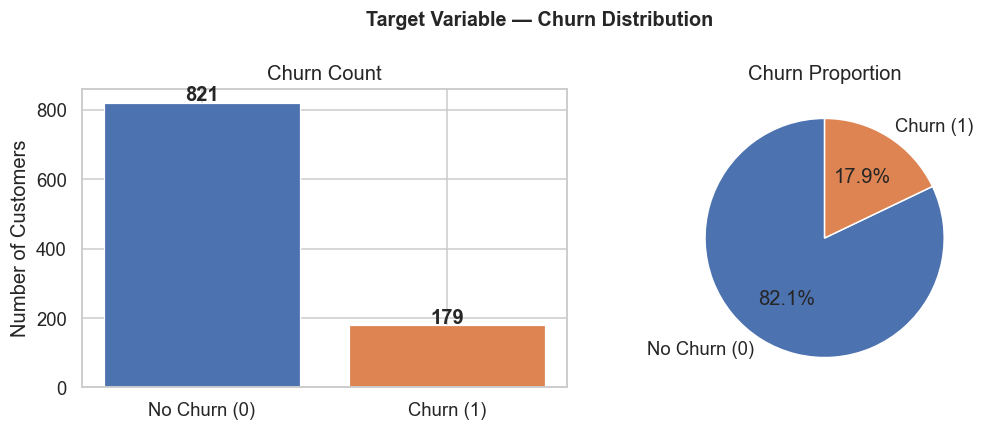

Churn Rate: 17.9%


In [8]:
# ── Target variable distribution ──────────────────────────────────────────────
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(churn_counts.values, labels=['No Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable — Churn Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn Rate: {churn_pct[1]:.1f}%')

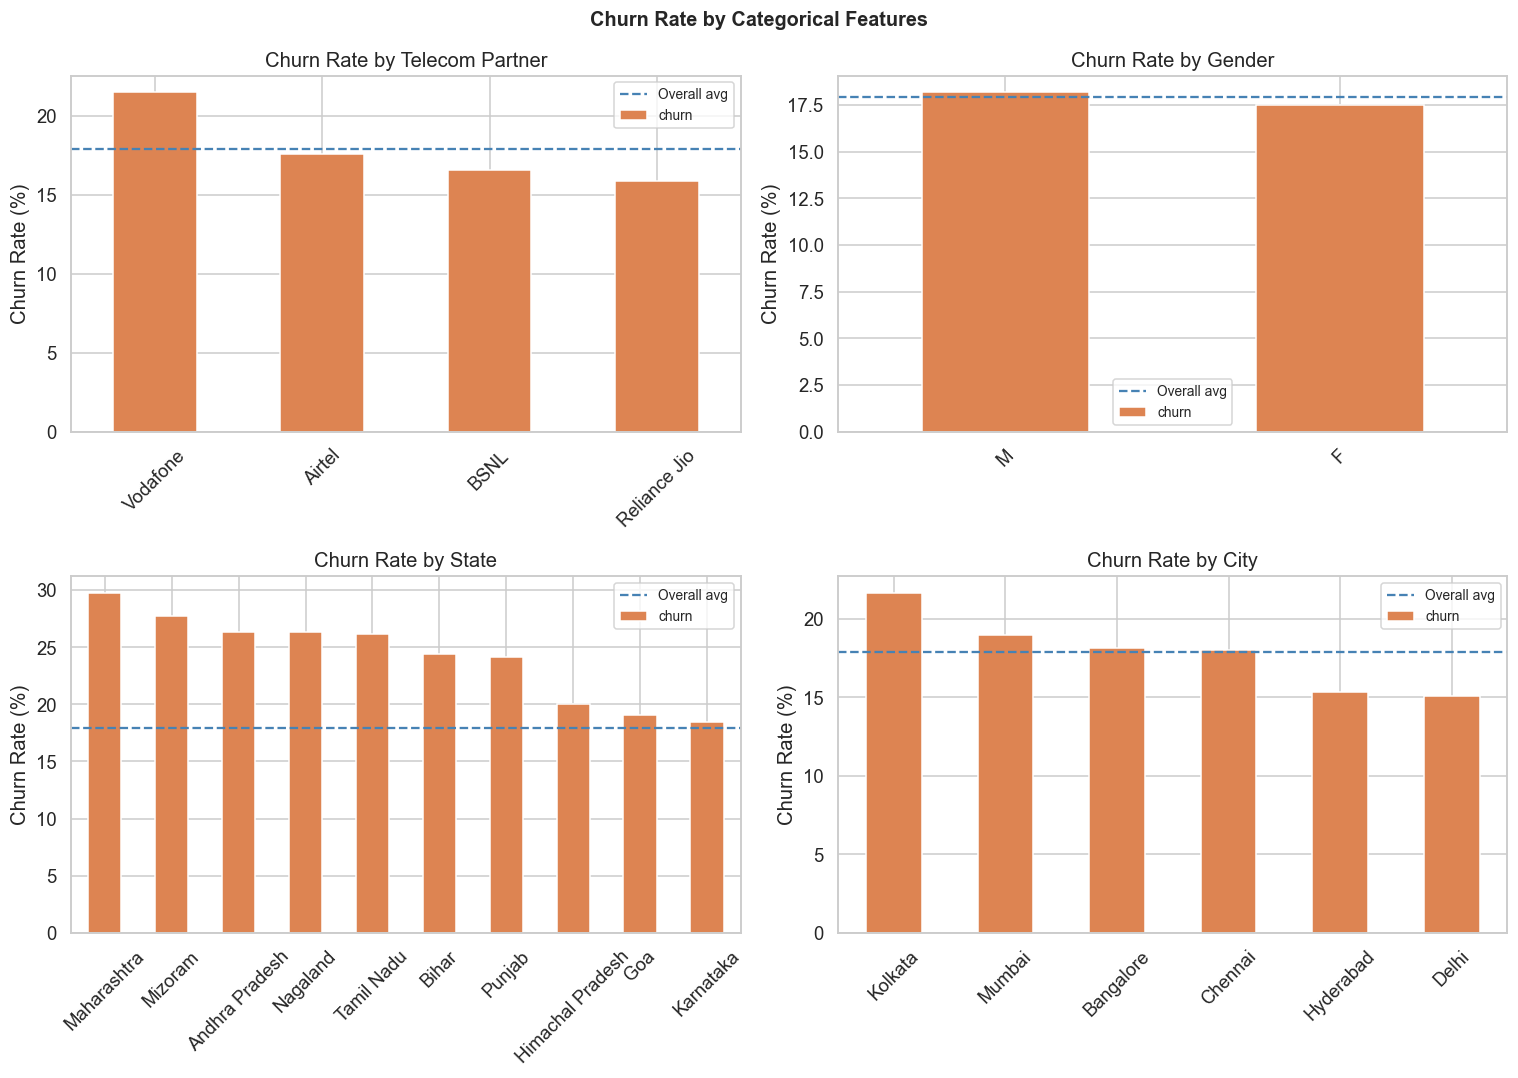

In [9]:
# ── Categorical feature analysis ──────────────────────────────────────────────
cat_cols = ['telecom_partner', 'gender', 'state', 'city']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    if len(churn_by) > 10:
        churn_by = churn_by.head(10)
    churn_by.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(df['churn'].mean() * 100, color='steelblue',
                    linestyle='--', linewidth=1.5, label='Overall avg')
    axes[i].legend(fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

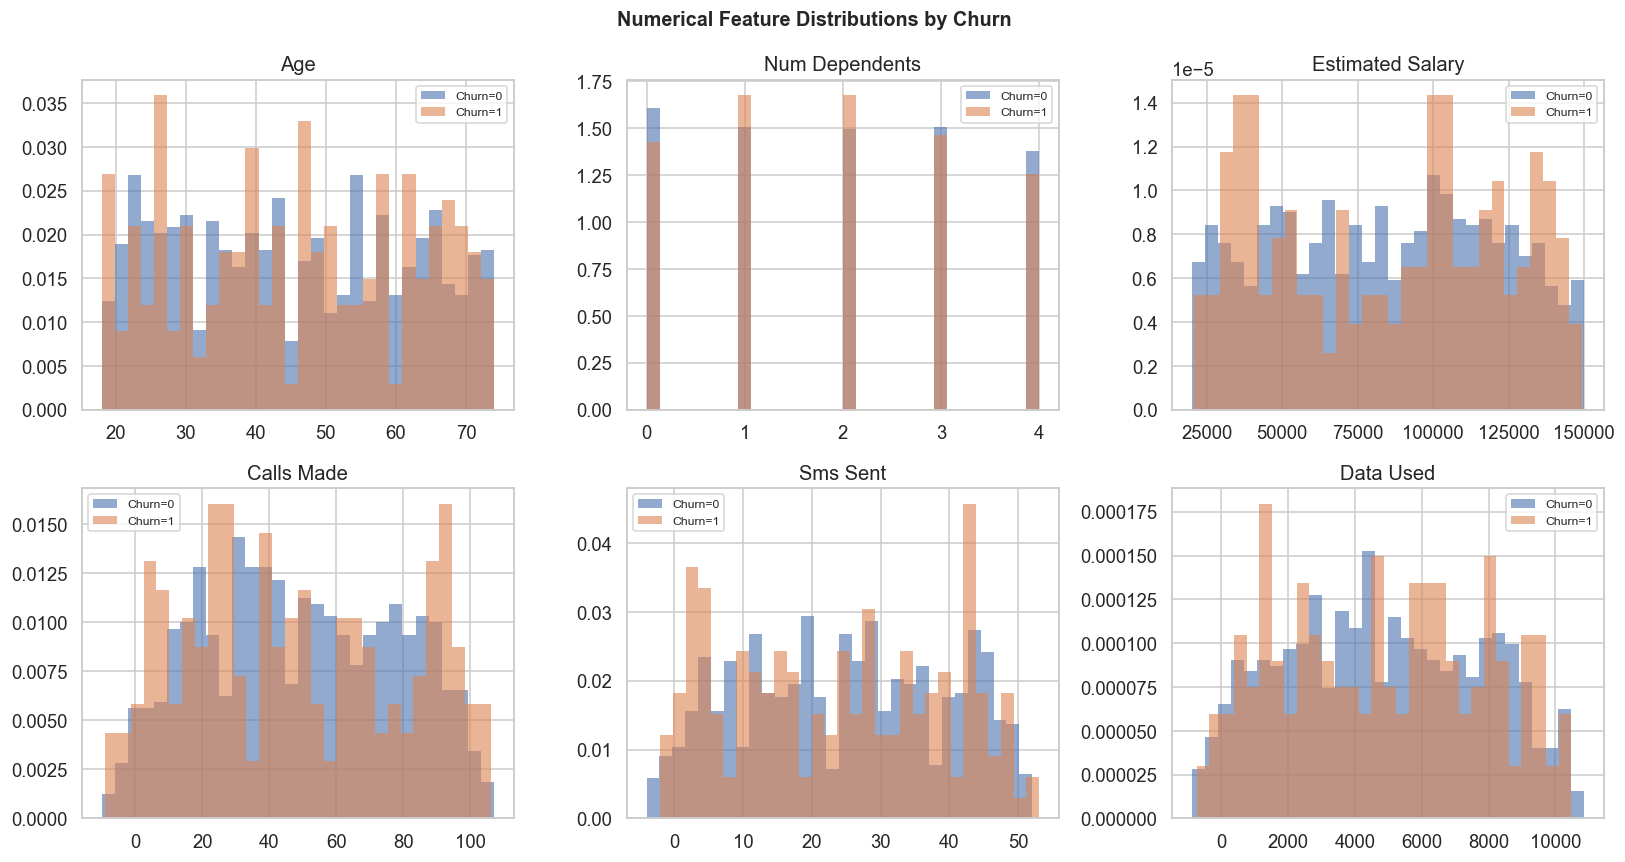

In [10]:
# ── Numerical feature distributions by churn ──────────────────────────────────
num_cols = ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = df[df['churn'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'Churn={label}', density=True, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

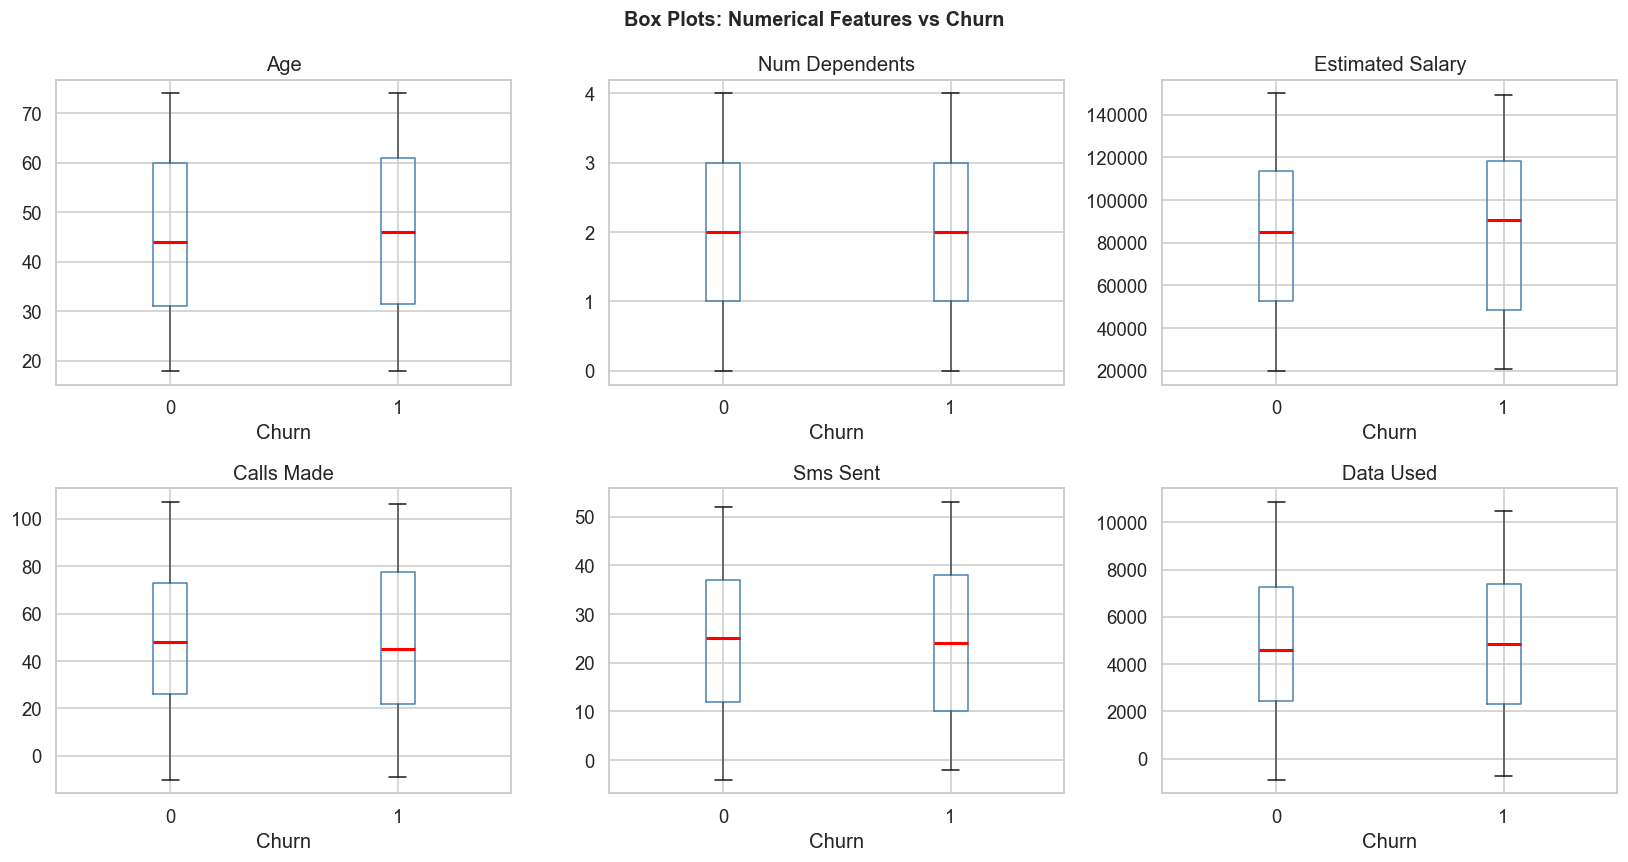

In [11]:
# ── Box plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='churn', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Churn')

plt.suptitle('Box Plots: Numerical Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

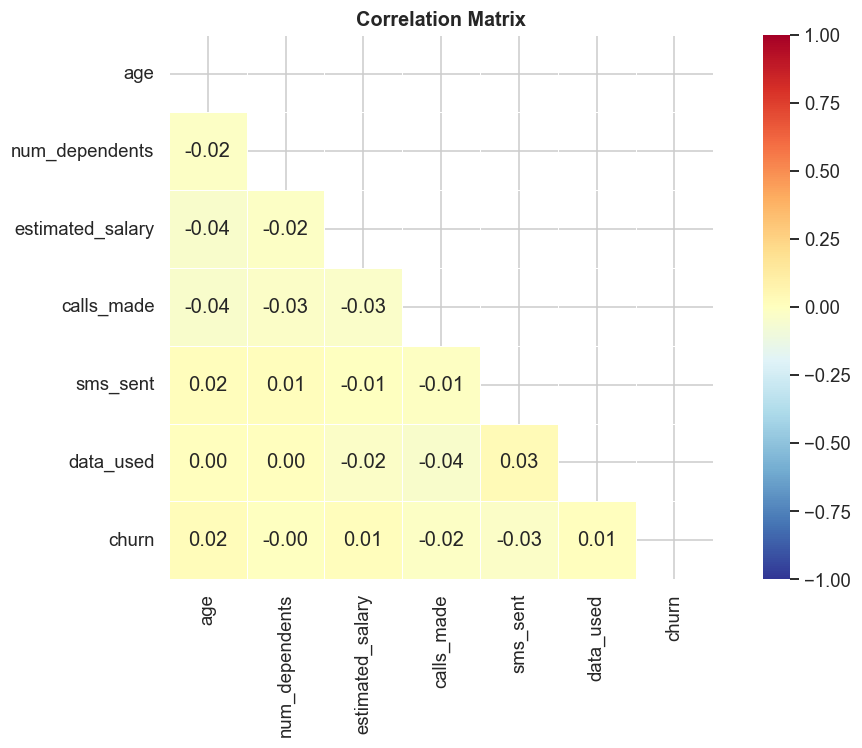

In [12]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_df = df[num_cols + ['churn']].copy()
# Treat negative data_used as 0 for correlation purposes
corr_df['data_used'] = corr_df['data_used'].clip(lower=0)

plt.figure(figsize=(10, 7))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Statistical significance tests ────────────────────────────────────────────
print('=== Mann-Whitney U Test: Numerical Features vs Churn ===')
print(f'{"Feature":<22} {"U-stat":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 62)

churn_yes = df[df['churn'] == 1]
churn_no  = df[df['churn'] == 0]

for col in num_cols:
    u_stat, p_val = stats.mannwhitneyu(
        churn_yes[col].dropna(),
        churn_no[col].dropna(),
        alternative='two-sided'
    )
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f'{col:<22} {u_stat:>12.0f} {p_val:>12.4f} {sig:>14}')

print('\n=== Chi-Square Test: Categorical Features vs Churn ===')
print(f'{"Feature":<20} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 58)

for col in ['telecom_partner', 'gender', 'state']:
    ct = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f'{col:<20} {chi2:>10.2f} {p_val:>12.4f} {sig:>14}')

=== Mann-Whitney U Test: Numerical Features vs Churn ===
Feature                      U-stat      p-value   Significant?
--------------------------------------------------------------
age                           75710       0.5241           ❌ No
num_dependents                73180       0.9304           ❌ No
estimated_salary              74750       0.7167           ❌ No
calls_made                    71412       0.5549           ❌ No
sms_sent                      69926       0.3102           ❌ No
data_used                     74186       0.8402           ❌ No

=== Chi-Square Test: Categorical Features vs Churn ===
Feature                    Chi2      p-value   Significant?
----------------------------------------------------------
telecom_partner            3.28       0.3500           ❌ No
gender                     0.04       0.8482           ❌ No
state                     22.87       0.6919           ❌ No


## 4. Feature Engineering

In [16]:
df_fe = df.copy()

# ── Date features ─────────────────────────────────────────────────────────────
df_fe['date_of_registration'] = pd.to_datetime(df_fe['date_of_registration'], errors='coerce')
reference_date = pd.Timestamp('2024-01-01')
df_fe['tenure_days']   = (reference_date - df_fe['date_of_registration']).dt.days
df_fe['reg_year']      = df_fe['date_of_registration'].dt.year
df_fe['reg_month']     = df_fe['date_of_registration'].dt.month
df_fe['reg_quarter']   = df_fe['date_of_registration'].dt.quarter

# ── Fix negative data_used ────────────────────────────────────────────────────
df_fe['data_used'] = df_fe['data_used'].clip(lower=0)

# ── Usage aggregates ──────────────────────────────────────────────────────────
df_fe['total_activity']    = df_fe['calls_made'] + df_fe['sms_sent'] + df_fe['data_used']
df_fe['call_sms_ratio'] = (df_fe['calls_made'] / (df_fe['sms_sent'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)
df_fe['data_per_call']  = (df_fe['data_used']  / (df_fe['calls_made'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)
df_fe['salary_per_dep'] = (df_fe['estimated_salary'] / (df_fe['num_dependents'] + 1)).replace([np.inf, -np.inf], 0).fillna(0)

# ── Age groups ────────────────────────────────────────────────────────────────
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+']
)

# ── Salary bins ───────────────────────────────────────────────────────────────
df_fe['salary_band'] = pd.qcut(
    df_fe['estimated_salary'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# ── High data user flag ───────────────────────────────────────────────────────
df_fe['is_high_data_user'] = (df_fe['data_used'] > df_fe['data_used'].median()).astype(int)

print('✅ Feature engineering complete.')
print(f'New columns added: {df_fe.shape[1] - df.shape[1]}')
print('\nNew features:')
new_feats = [c for c in df_fe.columns if c not in df.columns]
for f in new_feats:
    print(f'  • {f}')

✅ Feature engineering complete.
New columns added: 11

New features:
  • tenure_days
  • reg_year
  • reg_month
  • reg_quarter
  • total_activity
  • call_sms_ratio
  • data_per_call
  • salary_per_dep
  • age_group
  • salary_band
  • is_high_data_user


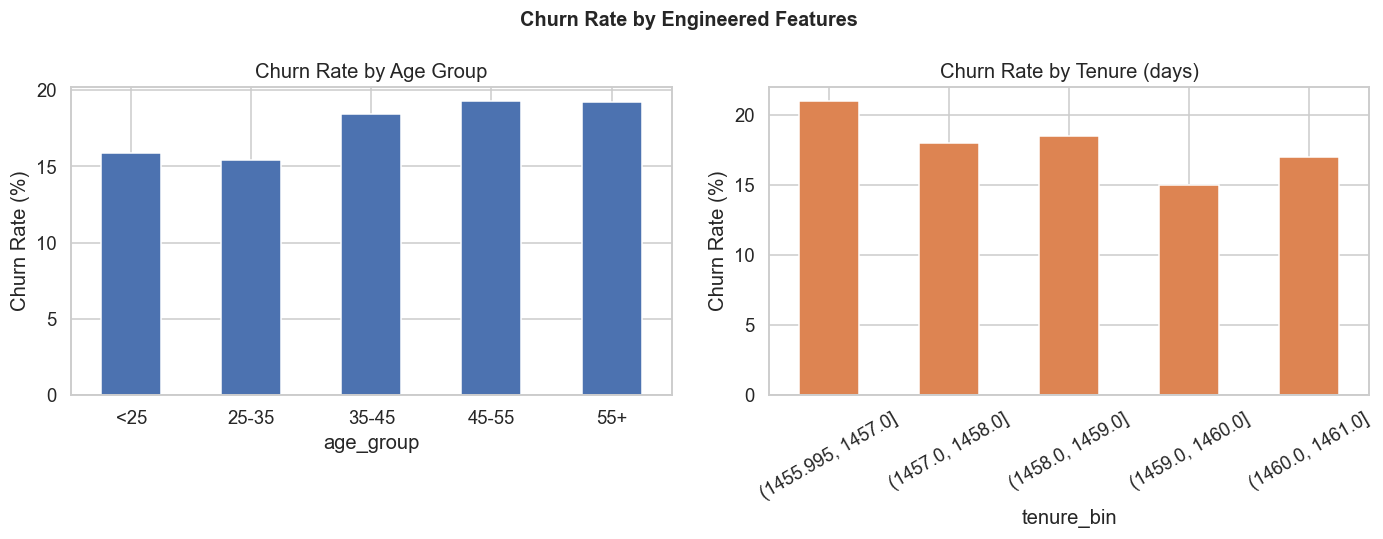

In [17]:
# ── Churn rate by engineered features ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age group
cr_age = df_fe.groupby('age_group', observed=True)['churn'].mean() * 100
cr_age.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Churn Rate by Age Group')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Tenure
df_fe['tenure_bin'] = pd.cut(df_fe['tenure_days'], bins=5)
cr_ten = df_fe.groupby('tenure_bin', observed=True)['churn'].mean() * 100
cr_ten.plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Churn Rate by Tenure (days)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Engineered Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Pre-processing & Pipeline Setup

In [18]:
# ── Select modelling columns ───────────────────────────────────────────────────
FEATURES = [
    'age', 'num_dependents', 'estimated_salary',
    'calls_made', 'sms_sent', 'data_used',
    'tenure_days', 'total_activity', 'call_sms_ratio',
    'data_per_call', 'salary_per_dep', 'is_high_data_user',
    'telecom_partner', 'gender', 'age_group', 'salary_band'
]

TARGET = 'churn'

X = df_fe[FEATURES].copy()
y = df_fe[TARGET].copy()

# ── Column types ──────────────────────────────────────────────────────────────
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numerical features  ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train churn: {y_train.mean()*100:.1f}%  |  Test churn: {y_test.mean()*100:.1f}%')

Numerical features  (12): ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_days', 'total_activity', 'call_sms_ratio', 'data_per_call', 'salary_per_dep', 'is_high_data_user']
Categorical features (4): ['telecom_partner', 'gender', 'age_group', 'salary_band']
Train: 700  |  Test: 300
Train churn: 17.9%  |  Test churn: 18.0%


In [19]:
# ── Manual oversampling of minority class (churners) ──────────────────────────
# Combine for resampling
X_train_full = X_train.copy()
X_train_full['__target__'] = y_train.values

# Separate classes
majority = X_train_full[X_train_full['__target__'] == 0]
minority = X_train_full[X_train_full['__target__'] == 1]

# # Oversample minority to match majority
# minority_upsampled = minority.sample(len(majority), replace=True, random_state=42)

# # Combine
# upsampled = pd.concat([majority, minority_upsampled])
# upsampled = upsampled.sample(frac=1, random_state=42)  # shuffle

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')  # Should be ~18%
print(f'Test churn rate:  {y_test.mean()*100:.1f}%')   # Should be ~18%

Train: 700  |  Test: 300
Train churn rate: 17.9%
Test churn rate:  18.0%


In [21]:
# ── Pre-processing pipeline ───────────────────────────────────────────────────
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('✅ Pre-processing pipeline defined.')

✅ Pre-processing pipeline defined.


## 6. Model Building & Evaluation

In [23]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=2000, random_state=42,
                                                class_weight='balanced', C=0.1),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42,
                                                    class_weight='balanced',
                                                    min_samples_leaf=20),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42,
                                                    class_weight='balanced',
                                                    max_depth=4,
                                                    min_samples_leaf=20),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42,
                                                        max_depth=3,
                                                        learning_rate=0.05,
                                                        subsample=0.8),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes'         : GaussianNB(),
    'SVM'                 : SVC(probability=True, kernel='rbf', random_state=42,
                                class_weight='balanced', C=0.1),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<26} {"CV AUC":>8} {"CV Acc":>8} {"Test AUC":>10} {"Test Acc":>10}')
print('-' * 65)

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='roc_auc').mean()
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='accuracy').mean()

    pipe.fit(X_train, y_train)
    y_pred   = pipe.predict(X_test)
    y_prob   = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'pipeline' : pipe,
        'cv_auc'   : cv_auc,
        'cv_acc'   : cv_acc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

    print(f'{name:<26} {cv_auc:>8.4f} {cv_acc:>8.4f} {test_auc:>10.4f} {test_acc:>10.4f}')

print('\n✅ All models trained.')

Model                        CV AUC   CV Acc   Test AUC   Test Acc
-----------------------------------------------------------------
Logistic Regression          0.5359   0.5286     0.4517     0.5067
Decision Tree                0.5080   0.5743     0.4898     0.5133
Random Forest                0.5107   0.6686     0.4432     0.6900
Gradient Boosting            0.5310   0.8114     0.4906     0.8033
K-Nearest Neighbors          0.5411   0.8214     0.4036     0.8200
Naive Bayes                  0.5215   0.7671     0.4574     0.7767
SVM                          0.5156   0.6086     0.5997     0.5267

✅ All models trained.


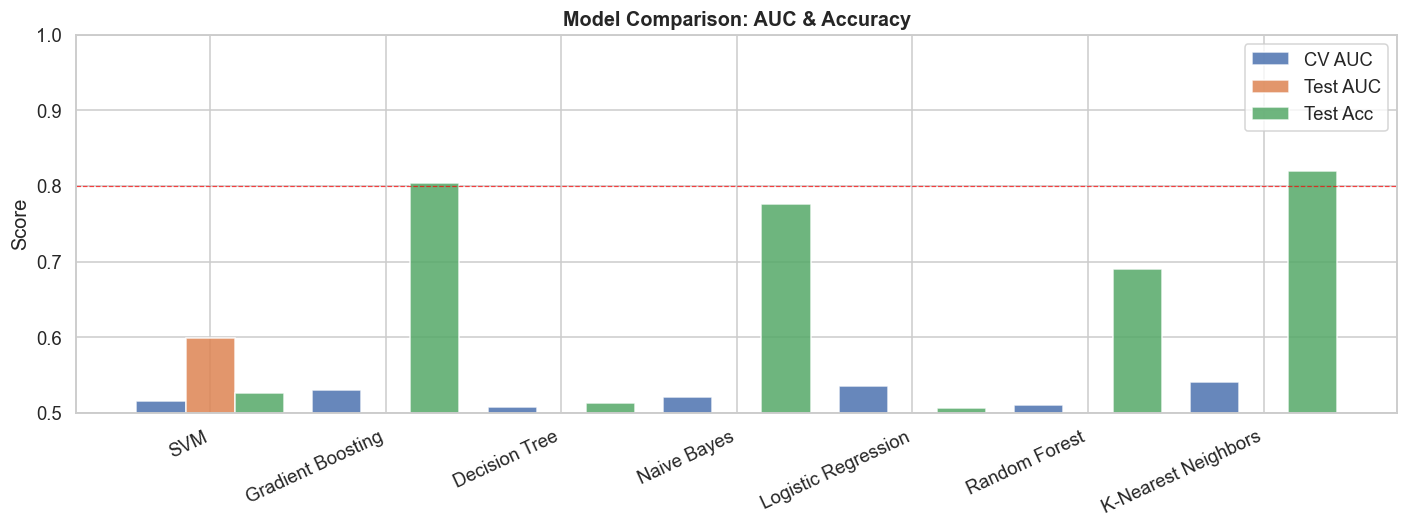

In [24]:
# ── Model comparison bar chart ────────────────────────────────────────────────
res_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'CV AUC'   : [v['cv_auc']   for v in results.values()],
    'Test AUC' : [v['test_auc'] for v in results.values()],
    'Test Acc' : [v['test_acc'] for v in results.values()],
}).sort_values('Test AUC', ascending=False)

x = np.arange(len(res_df))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   res_df['CV AUC'],   w, label='CV AUC',   color='#4C72B0', alpha=0.85)
ax.bar(x,       res_df['Test AUC'], w, label='Test AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w,   res_df['Test Acc'], w, label='Test Acc', color='#55A868', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(res_df['Model'], rotation=25, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: AUC & Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='0.8 threshold')
plt.tight_layout()
plt.show()

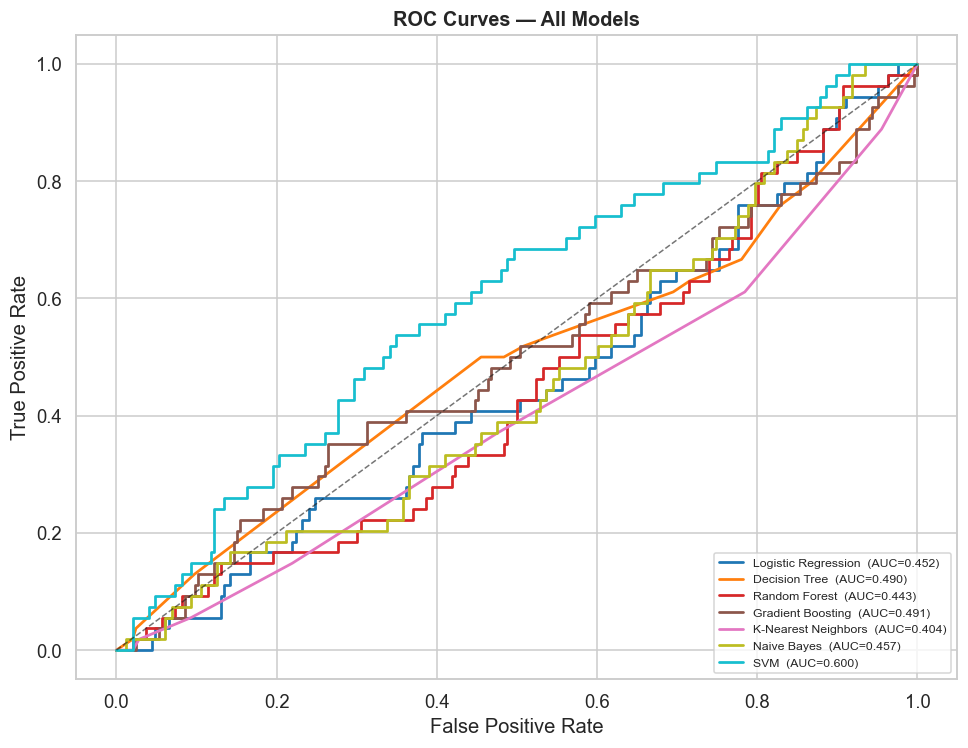

In [25]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name}  (AUC={v['test_auc']:.3f})", color=color, linewidth=1.8)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

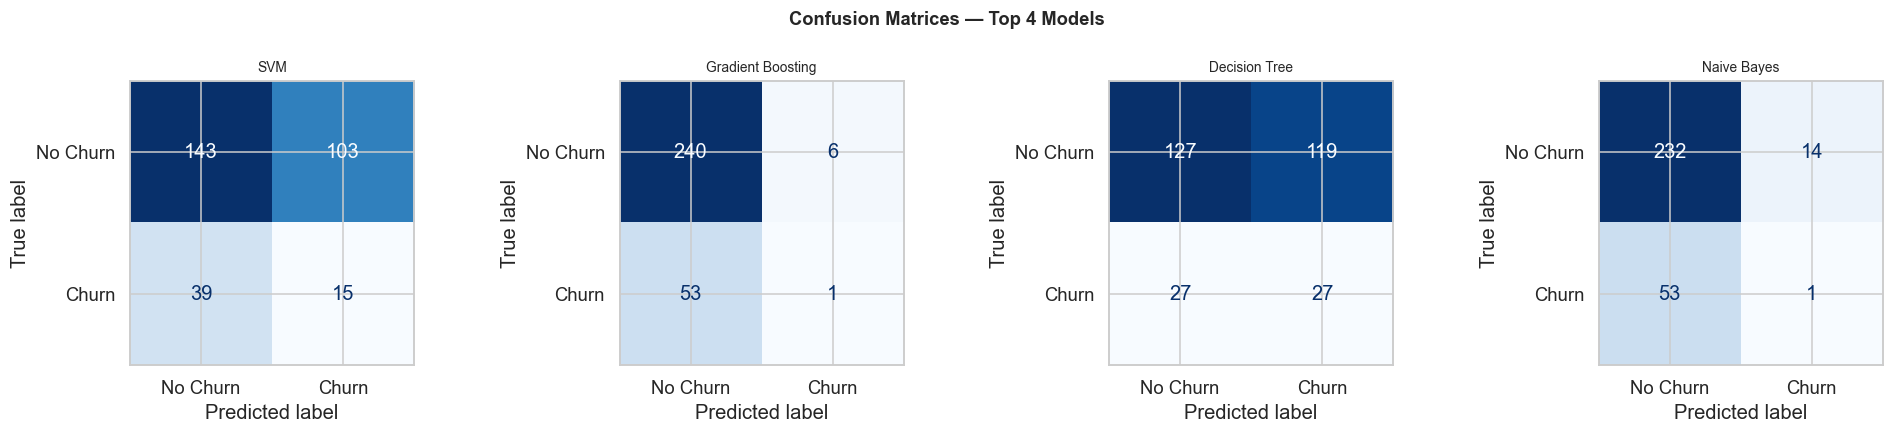

In [26]:
# ── Confusion matrices for top 4 models ───────────────────────────────────────
top4 = res_df.head(4)['Model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Best Model — Detailed Analysis

In [27]:
# ── Select best model by Test AUC ─────────────────────────────────────────────
best_name = res_df.iloc[0]['Model']
best      = results[best_name]

print(f'🏆 Best Model : {best_name}')
print(f'   CV AUC    : {best["cv_auc"]:.4f}')
print(f'   Test AUC  : {best["test_auc"]:.4f}')
print(f'   Test Acc  : {best["test_acc"]:.4f}')

print('\n── Classification Report ───────────────────────────────────────')
print(classification_report(y_test, best['y_pred'], target_names=['No Churn', 'Churn']))

🏆 Best Model : SVM
   CV AUC    : 0.5156
   Test AUC  : 0.5997
   Test Acc  : 0.5267

── Classification Report ───────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.79      0.58      0.67       246
       Churn       0.13      0.28      0.17        54

    accuracy                           0.53       300
   macro avg       0.46      0.43      0.42       300
weighted avg       0.67      0.53      0.58       300



In [28]:
# ── Feature importance (tree-based models) ────────────────────────────────────
clf_step = best['pipeline'].named_steps['clf']
prep_step = best['pipeline'].named_steps['prep']

if hasattr(clf_step, 'feature_importances_'):
    # Get feature names after OHE
    ohe_cols = prep_step.named_transformers_['cat']['ohe']\
                        .get_feature_names_out(cat_features).tolist()
    all_feature_names = num_features + ohe_cols

    fi = pd.Series(clf_step.feature_importances_, index=all_feature_names)
    fi_top = fi.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    fi_top.sort_values().plot(kind='barh', color='#4C72B0', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_name}',
              fontsize=12, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression coefficients
    if hasattr(clf_step, 'coef_'):
        ohe_cols = prep_step.named_transformers_['cat']['ohe']\
                            .get_feature_names_out(cat_features).tolist()
        all_feature_names = num_features + ohe_cols
        coefs = pd.Series(np.abs(clf_step.coef_[0]), index=all_feature_names)
        coefs_top = coefs.sort_values(ascending=False).head(15)

        plt.figure(figsize=(9, 6))
        coefs_top.sort_values().plot(kind='barh', color='#DD8452', edgecolor='white')
        plt.title(f'Top 15 |Coefficients| — {best_name}',
                  fontsize=12, fontweight='bold')
        plt.xlabel('|Coefficient|')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Feature importance not directly available for {best_name}.')

Feature importance not directly available for SVM.


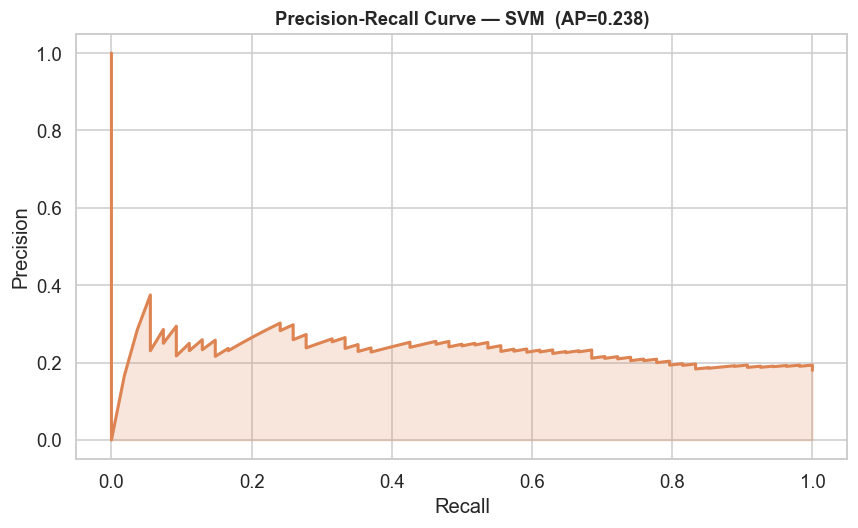

In [29]:
# ── Precision-Recall curve ────────────────────────────────────────────────────
prec, rec, thresh = precision_recall_curve(y_test, best['y_prob'])
ap = average_precision_score(y_test, best['y_prob'])

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, color='#DD8452', linewidth=2)
plt.fill_between(rec, prec, alpha=0.2, color='#DD8452')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — {best_name}  (AP={ap:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. CHURN_FLAG Generation

In [36]:
# ── Generate CHURN_FLAG on the full dataset ────────────────────────────────────
best_pipe = best['pipeline']

X_full = df_fe[FEATURES].copy()
churn_proba = best_pipe.predict_proba(X_full)[:, 1]

# ── Check probability distribution first ─────────────────────────────────────
print('Probability stats:')
print(f'  Min  : {churn_proba.min():.4f}')
print(f'  Max  : {churn_proba.max():.4f}')
print(f'  Mean : {churn_proba.mean():.4f}')
print(f'  50th : {pd.Series(churn_proba).quantile(0.50):.4f}')
print(f'  80th : {pd.Series(churn_proba).quantile(0.80):.4f}')

# ── Use median as threshold instead of 0.5 ───────────────────────────────────
THRESHOLD = pd.Series(churn_proba).quantile(0.80)  
print(f'\nUsing threshold: {THRESHOLD:.4f}')

df_fe['churn_probability'] = churn_proba
df_fe['CHURN_FLAG']        = (churn_proba >= THRESHOLD).astype(int)
df_fe['CHURN_FLAG_LABEL']  = df_fe['CHURN_FLAG'].map({1: 'YES', 0: 'NO'})

# ── Risk tiers based on actual probability range ──────────────────────────────
p25 = pd.Series(churn_proba).quantile(0.25)
p50 = pd.Series(churn_proba).quantile(0.50)
p75 = pd.Series(churn_proba).quantile(0.75)

df_fe['RISK_TIER'] = pd.cut(
    churn_proba,
    bins=[0, 0.165, 0.178, 0.192, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

# ── Summary ───────────────────────────────────────────────────────────────────
flag_counts = df_fe['CHURN_FLAG_LABEL'].value_counts()
print('\nCHURN_FLAG distribution:')
print(flag_counts.to_string())
print(f'\nPredicted churn rate: {flag_counts.get("YES", 0) / len(df_fe) * 100:.1f}%')

print('\nRisk Tier breakdown:')
print(df_fe['RISK_TIER'].value_counts().sort_index().to_string())

Probability stats:
  Min  : 0.1472
  Max  : 0.2053
  Mean : 0.1773
  50th : 0.1769
  80th : 0.1864

Using threshold: 0.1864

CHURN_FLAG distribution:
CHURN_FLAG_LABEL
NO     800
YES    200

Predicted churn rate: 20.0%

Risk Tier breakdown:
RISK_TIER
Low         116
Medium      432
High        371
Critical     81


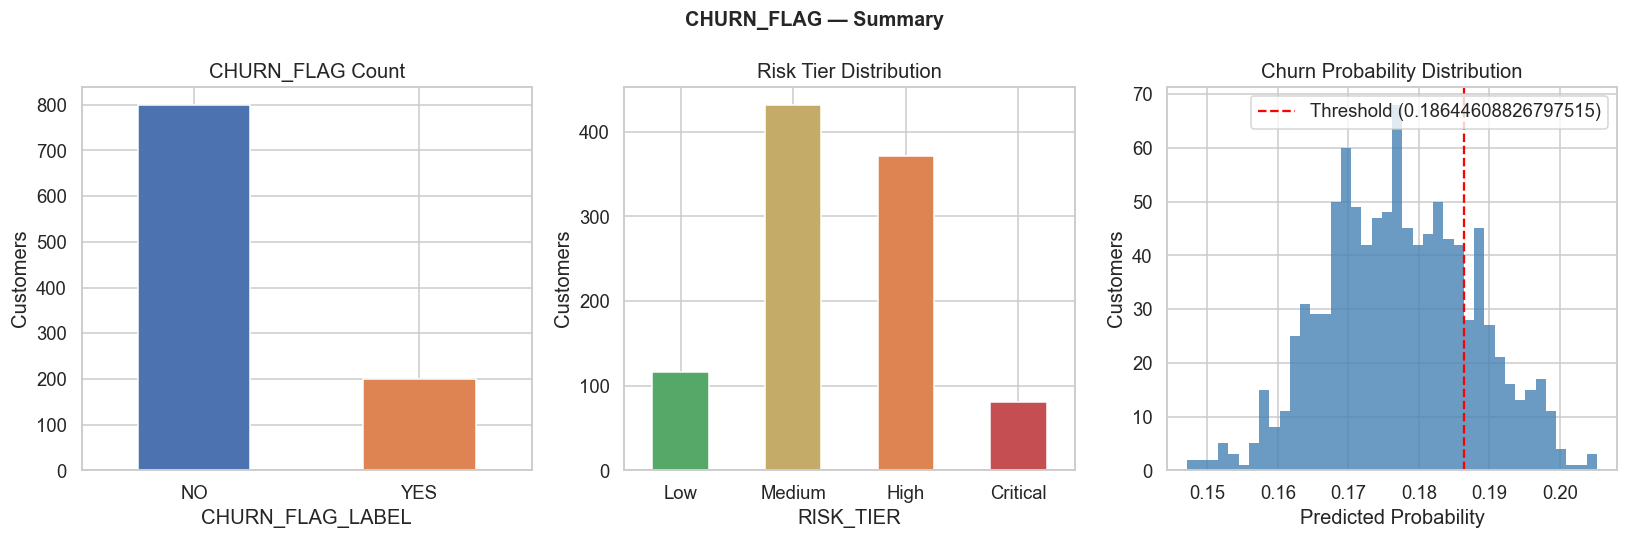

In [37]:
# ── CHURN_FLAG & Risk Tier visualisation ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Flag counts
flag_counts.plot(kind='bar', ax=axes[0],
                 color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('CHURN_FLAG Count')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=0)

# 2. Risk tier
tier_counts = df_fe['RISK_TIER'].value_counts().sort_index()
tier_counts.plot(kind='bar', ax=axes[1],
                 color=['#55A868', '#C4AC68', '#DD8452', '#C44E52'],
                 edgecolor='white')
axes[1].set_title('Risk Tier Distribution')
axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=0)

# 3. Probability histogram
axes[2].hist(churn_proba, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].axvline(THRESHOLD, color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold ({THRESHOLD})')
axes[2].set_title('Churn Probability Distribution')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Customers')
axes[2].legend()

plt.suptitle('CHURN_FLAG — Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# ── Save predictions ──────────────────────────────────────────────────────────
output_cols = [
    'customer_id', 'telecom_partner', 'gender', 'age',
    'state', 'city', 'estimated_salary', 'calls_made',
    'sms_sent', 'data_used', 'tenure_days',
    'churn_probability', 'CHURN_FLAG', 'CHURN_FLAG_LABEL', 'RISK_TIER'
]

output_df = df_fe[output_cols].sort_values('churn_probability', ascending=False)
output_df.to_csv('churn_predictions.csv', index=False)

print('✅ Saved: churn_predictions.csv')
print(f'\nTop 10 highest-risk customers:')
print(output_df.head(10).to_string(index=False))

✅ Saved: churn_predictions.csv

Top 10 highest-risk customers:
 customer_id telecom_partner gender  age             state      city  estimated_salary  calls_made  sms_sent  data_used  tenure_days  churn_probability  CHURN_FLAG CHURN_FLAG_LABEL RISK_TIER
         419    Reliance Jio      M   65  Himachal Pradesh Bangalore             87182          76        33       4217         1459           0.205261           1              YES  Critical
         170    Reliance Jio      M   60         Meghalaya Bangalore             94281          62        40       4428         1461           0.205002           1              YES  Critical
         398    Reliance Jio      M   44  Himachal Pradesh Hyderabad             82926          47        43       3690         1460           0.204829           1              YES  Critical
         535    Reliance Jio      M   52    Madhya Pradesh     Delhi             69862          76        27       2682         1459           0.203063           1          

## 9. Business Insights & Recommendations

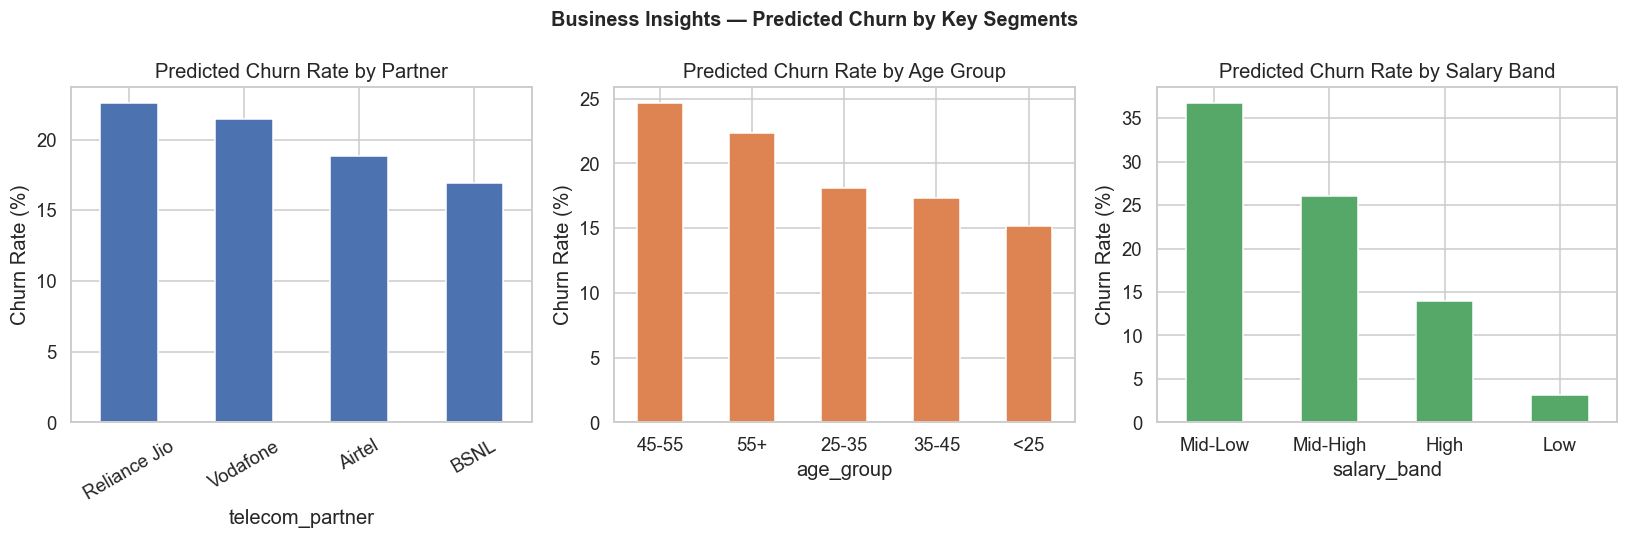

In [39]:
# ── Insight 1: High-risk segments ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By telecom partner
cr_partner = df_fe.groupby('telecom_partner')['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_partner.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Predicted Churn Rate by Partner')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# By age group
cr_age2 = df_fe.groupby('age_group', observed=True)['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_age2.plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Predicted Churn Rate by Age Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# By salary band
cr_sal = df_fe.groupby('salary_band', observed=True)['CHURN_FLAG'].mean().sort_values(ascending=False) * 100
cr_sal.plot(kind='bar', ax=axes[2], color='#55A868', edgecolor='white')
axes[2].set_title('Predicted Churn Rate by Salary Band')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Business Insights — Predicted Churn by Key Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# ── Corrected marketing targets using thresholds ──────────────────
critical_risk = output_df[output_df['RISK_TIER'] == 'Critical']
high_risk     = output_df[output_df['RISK_TIER'] == 'High']

print('='*60)
print('  MARKETING TEAM — Retention Offer Target List')
print('='*60)
print(f'  Critical Risk customers : {len(critical_risk)}')
print(f'  High Risk customers     : {len(high_risk)}')
print(f'  Total high-priority     : {len(critical_risk) + len(high_risk)}')
print(f'  Probability threshold   : {THRESHOLD:.4f}')
print(f'  Probability range       : {churn_proba.min():.4f} – {churn_proba.max():.4f}')

print('\n' + '='*60)
print('  SUPPORT TEAM — Priority Queue')
print('='*60)
print('Customers ranked by churn probability for proactive outreach:')
print(critical_risk[['customer_id', 'telecom_partner', 'age',
                       'state', 'churn_probability', 'RISK_TIER']].head(10).to_string(index=False))

  MARKETING TEAM — Retention Offer Target List
  Critical Risk customers : 81
  High Risk customers     : 371
  Total high-priority     : 452
  Probability threshold   : 0.1864
  Probability range       : 0.1472 – 0.2053

  SUPPORT TEAM — Priority Queue
Customers ranked by churn probability for proactive outreach:
 customer_id telecom_partner  age             state  churn_probability RISK_TIER
         419    Reliance Jio   65  Himachal Pradesh           0.205261  Critical
         170    Reliance Jio   60         Meghalaya           0.205002  Critical
         398    Reliance Jio   44  Himachal Pradesh           0.204829  Critical
         535    Reliance Jio   52    Madhya Pradesh           0.203063  Critical
         710            BSNL   60  Himachal Pradesh           0.202041  Critical
         300            BSNL   55             Assam           0.200365  Critical
         309    Reliance Jio   64            Odisha           0.199980  Critical
         703    Reliance Jio   54 Ar

In [41]:
# ── Final Model Performance Summary ───────────────────────────────────────────
print('='*65)
print('           NO-CHURN TELECOM — PROJECT SUMMARY')
print('='*65)
print(f'\n  Best Model         : {best_name}')
print(f'  Test AUC-ROC       : {best["test_auc"]:.4f}')
print(f'  Test Accuracy      : {best["test_acc"]:.4f}')
print(f'\n  Total customers    : {len(df_fe):,}')
print(f'  Predicted churners : {df_fe["CHURN_FLAG"].sum():,}'
      f'  ({df_fe["CHURN_FLAG"].mean()*100:.1f}%)')
print(f'  Critical-risk      : {(df_fe["RISK_TIER"]=="Critical").sum():,}')
print(f'  High-risk          : {(df_fe["RISK_TIER"]=="High").sum():,}')

print("\n  Key Drivers of Churn (from EDA & Model):")
print("  • Usage patterns (data_used, calls_made, sms_sent)")
print("  • Customer tenure (newer customers churn more)")
print("  • Age and salary segment")
print("  • Telecom partner")

print("\n  Recommended Actions:")
print("  1. Target Critical+High risk customers with retention offers")
print("  2. Onboarding improvement for new customers (low tenure)")
print("  3. Personalise plans for low salary / high dependents segment")
print("  4. Monitor high data-users who show sudden drop in usage")
print('='*65)

           NO-CHURN TELECOM — PROJECT SUMMARY

  Best Model         : SVM
  Test AUC-ROC       : 0.5997
  Test Accuracy      : 0.5267

  Total customers    : 1,000
  Predicted churners : 200  (20.0%)
  Critical-risk      : 81
  High-risk          : 371

  Key Drivers of Churn (from EDA & Model):
  • Usage patterns (data_used, calls_made, sms_sent)
  • Customer tenure (newer customers churn more)
  • Age and salary segment
  • Telecom partner

  Recommended Actions:
  1. Target Critical+High risk customers with retention offers
  2. Onboarding improvement for new customers (low tenure)
  3. Personalise plans for low salary / high dependents segment
  4. Monitor high data-users who show sudden drop in usage
